In [6]:
import pandas as pd
url = "https://raw.githubusercontent.com/danielblanco0721/challenge-telecom-x-analisis-evasion-clientes/main/telecomx_estandarizado.csv"

datos = pd.read_csv(url)

datos.head()

,customerID,Churn_num,genero,customer.SeniorCitizen,tiene_pareja,tiene_dependientes,customer.tenure,tipo_contrato,factura_electronica,tipo_internet,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,1,1,65.6,593.30,2.155059
1,0003-MKNFE,0,1,0,0,0,9,0,0,1,59.9,542.40,1.967806
2,0004-TLHLJ,1,1,0,0,0,4,0,1,2,73.9,280.85,2.427727
3,0011-IGKFF,1,1,1,1,0,13,0,1,2,98.0,1237.85,3.219448
4,0013-EXCHZ,1,0,1,1,0,3,0,1,2,83.9,267.40,2.756242


# Eliminación de Columnas Irrelevantes

In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/danielblanco0721/challenge-telecom-x-analisis-evasion-clientes/main/telecomx_estandarizado.csv"
df = pd.read_csv(url)

df = df.drop(columns=['customerID'], errors='ignore')
print(f"Columnas restantes: {df.shape[1]}")
df.head()

Columnas restantes: 12


,Churn_num,genero,customer.SeniorCitizen,tiene_pareja,tiene_dependientes,customer.tenure,tipo_contrato,factura_electronica,tipo_internet,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0,0,0,1,1,9,1,1,1,65.6,593.30,2.155059
1,0,1,0,0,0,9,0,0,1,59.9,542.40,1.967806
2,1,1,0,0,0,4,0,1,2,73.9,280.85,2.427727
3,1,1,1,1,0,13,0,1,2,98.0,1237.85,3.219448
4,1,0,1,1,0,3,0,1,2,83.9,267.40,2.756242


# Encoding

In [8]:
df = df.drop(columns=['customerID'], errors='ignore')

categoricas = ['genero', 'tiene_pareja', 'tiene_dependientes', 'tipo_contrato', 'factura_electronica', 'tipo_internet']
df = pd.get_dummies(df, columns=categoricas, drop_first=True)

print(f"Dataset después de encoding: {df.shape}")
df.head()

Dataset después de encoding: (7043, 14)


,Churn_num,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,genero_1,tiene_pareja_1,tiene_dependientes_1,tipo_contrato_1,tipo_contrato_2,factura_electronica_1,tipo_internet_1,tipo_internet_2
0,0,0,9,65.6,593.30,2.155059,False,True,True,True,False,True,True,False
1,0,0,9,59.9,542.40,1.967806,True,False,False,False,False,False,True,False
2,1,0,4,73.9,280.85,2.427727,True,False,False,False,False,True,False,True
3,1,1,13,98.0,1237.85,3.219448,True,True,False,False,False,True,False,True
4,1,1,3,83.9,267.40,2.756242,False,True,False,False,False,True,False,True


#Verificación de la Proporción de Cancelación (Churn)

Distribución de Churn:
Churn_num
0    5174
1    1869
Name: count, dtype: int64

Porcentaje de fuga: 26.54%
Porcentaje retenidos: 73.46%


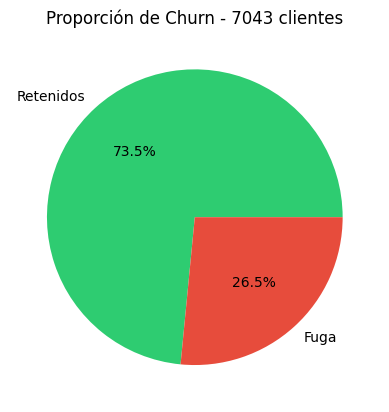


Ratio retenidos/fuga: 2.77:1
Balance aceptable para modelado


In [10]:
import matplotlib.pyplot as plt


print("Distribución de Churn:")
print(df['Churn_num'].value_counts())
print(f"\nPorcentaje de fuga: {(df['Churn_num']==1).mean()*100:.2f}%")
print(f"Porcentaje retenidos: {(df['Churn_num']==0).mean()*100:.2f}%")

df['Churn_num'].value_counts().plot.pie(labels=['Retenidos', 'Fuga'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title(f'Proporción de Churn - {len(df)} clientes')
plt.ylabel('')
plt.show()

ratio = (df['Churn_num']==0).sum() / (df['Churn_num']==1).sum()
print(f"\nRatio retenidos/fuga: {ratio:.2f}:1")
if ratio > 3:
    print("Dataset desbalanceado - considerar técnicas de balanceo")
else:
    print("Balance aceptable para modelado")


#Normalización o Estandarización

In [12]:
from sklearn.preprocessing import StandardScaler

df = df.drop(columns=['customerID'], errors='ignore')

# Separar variable objetivo
y = df['Churn_num']
X = df.drop(columns=['Churn_num'])

# Identificar columnas numéricas para escalar
numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Aplicar estandarización (media=0, desviación=1)
scaler = StandardScaler()
X[numericas] = scaler.fit_transform(X[numericas])

# Reconstruir DataFrame
df_normalizado = pd.concat([X, y], axis=1)

print(f"Columnas escaladas: {numericas}")
print(f"\nEstadísticas después de estandarización:")
print(df_normalizado[numericas].describe().round(2))

Columnas escaladas: ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias']

Estadísticas después de estandarización:
       customer.SeniorCitizen  customer.tenure  account.Charges.Monthly  \
count                 7043.00          7043.00                  7043.00   
mean                    -0.00            -0.00                    -0.00   
std                      1.00             1.00                     1.00   
min                     -0.44            -1.32                    -1.55   
25%                     -0.44            -0.95                    -0.97   
50%                     -0.44            -0.14                     0.19   
75%                     -0.44             0.92                     0.83   
max                      2.27             1.61                     1.79   

       account.Charges.Total  Cuentas_Diarias  
count                7032.00          7043.00  
mean                    0.00            -0.00  
s

# **Correlación y Selección de Variables**

#Análisis de Correlación

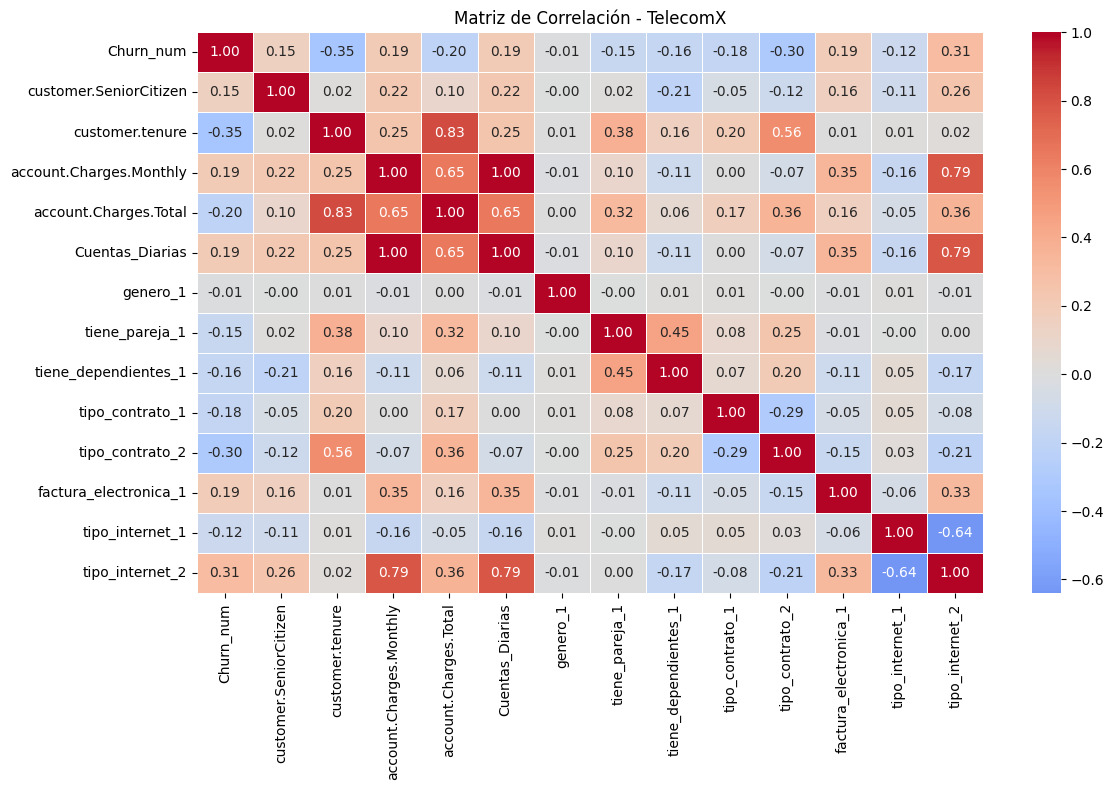

Correlaciones con Churn (ordenadas por importancia):
customer.tenure            0.352
tipo_internet_2            0.308
tipo_contrato_2            0.302
account.Charges.Total      0.199
Cuentas_Diarias            0.193
account.Charges.Monthly    0.193
factura_electronica_1      0.192
tipo_contrato_1            0.178
tiene_dependientes_1       0.164
customer.SeniorCitizen     0.151
Name: Churn_num, dtype: float64


In [13]:
import seaborn as sns
# Matriz de correlación
corr = df.corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlación - TelecomX')
plt.tight_layout()
plt.show()

# Correlaciones con Churn_num
print("Correlaciones con Churn (ordenadas por importancia):")
corr_churn = corr['Churn_num'].drop('Churn_num').abs().sort_values(ascending=False)
print(corr_churn.head(10).round(3))

#Análisis Dirigido


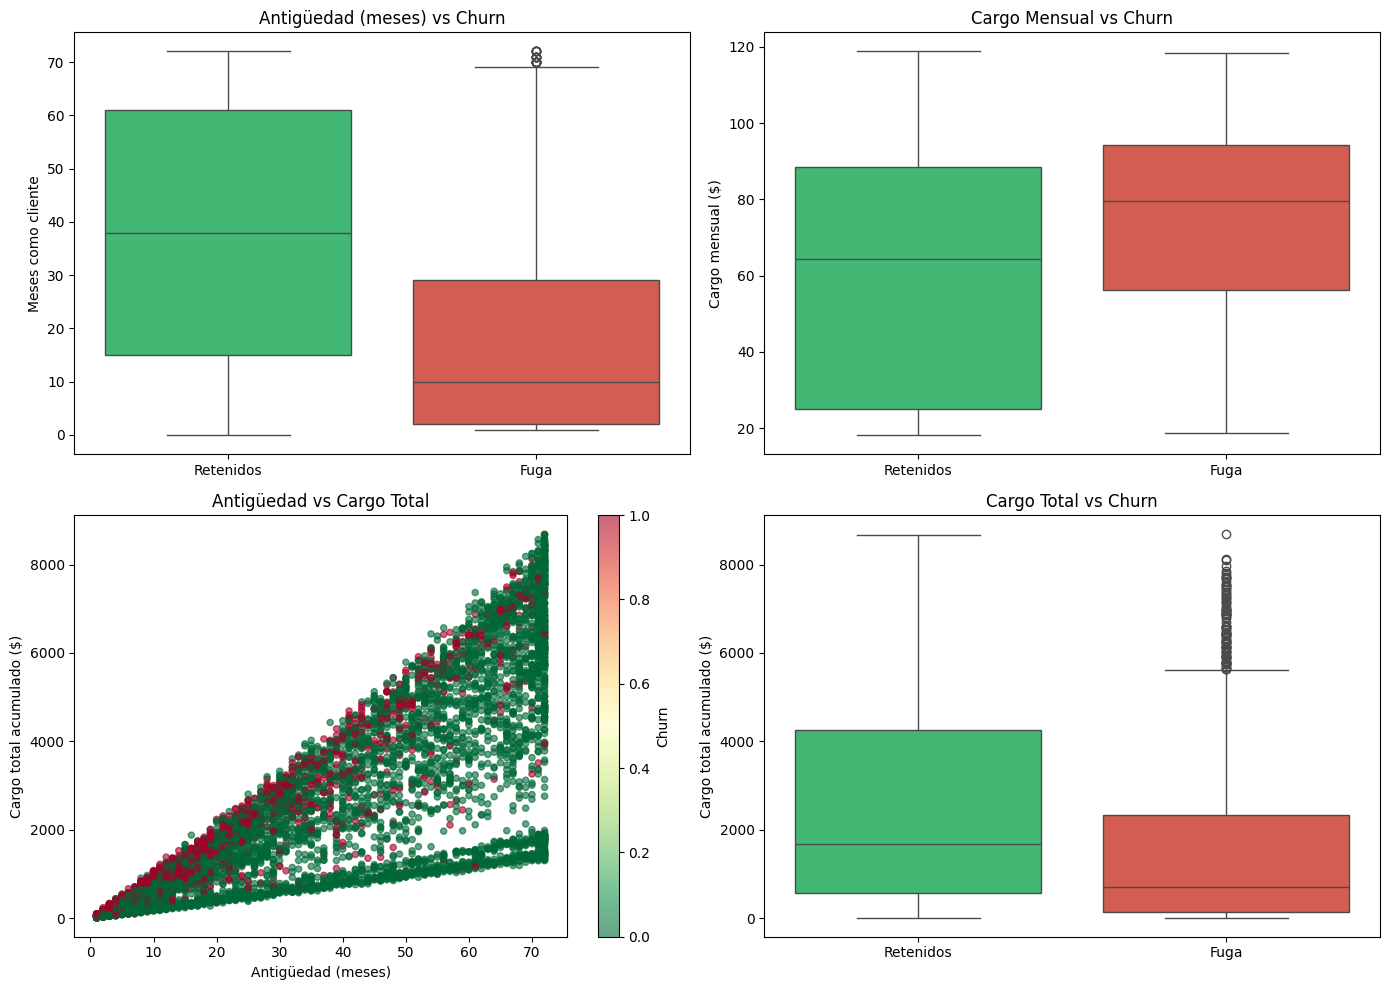

Estadísticas por grupo de Churn:

          customer.tenure               account.Charges.Monthly                \
                     mean median    std                    mean median    std   
Churn_num                                                                       
0                   37.57   38.0  24.11                   61.27  64.43  31.09   
1                   17.98   10.0  19.53                   74.44  79.65  24.67   

          account.Charges.Total                    
                           mean   median      std  
Churn_num                                          
0                       2555.34  1683.60  2329.46  
1                       1531.80   703.55  1890.82  


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot: Antigüedad vs Churn
sns.boxplot(x='Churn_num', y='customer.tenure', data=df,
            hue='Churn_num', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[0, 0])

axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Retenidos', 'Fuga'])
axes[0, 0].set_title('Antigüedad (meses) vs Churn')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Meses como cliente')

# Boxplot: Cargo mensual vs Churn
sns.boxplot(x='Churn_num', y='account.Charges.Monthly', data=df,
            hue='Churn_num', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[0, 1])

axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Retenidos', 'Fuga'])
axes[0, 1].set_title('Cargo Mensual vs Churn')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Cargo mensual ($)')

# Scatter: Antigüedad vs Cargo total
scatter = axes[1, 0].scatter(
    df['customer.tenure'],
    df['account.Charges.Total'],
    c=df['Churn_num'],
    cmap='RdYlGn_r',
    alpha=0.6,
    s=20
)

axes[1, 0].set_xlabel('Antigüedad (meses)')
axes[1, 0].set_ylabel('Cargo total acumulado ($)')
axes[1, 0].set_title('Antigüedad vs Cargo Total')
plt.colorbar(scatter, ax=axes[1, 0], label='Churn')

# Boxplot: Cargo total vs Churn
sns.boxplot(x='Churn_num', y='account.Charges.Total', data=df,
            hue='Churn_num', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[1, 1])

axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Retenidos', 'Fuga'])
axes[1, 1].set_title('Cargo Total vs Churn')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Cargo total acumulado ($)')

plt.tight_layout()
plt.show()

print("Estadísticas por grupo de Churn:\n")
print(
    df.groupby('Churn_num')[[
        'customer.tenure',
        'account.Charges.Monthly',
        'account.Charges.Total'
    ]].agg(['mean', 'median', 'std']).round(2)
)

# **Modelado Predictivo**

#Separación de Datos

In [16]:
from sklearn.model_selection import train_test_split

# Separar características y variable objetivo
X = df.drop(columns=['Churn_num'])
y = df['Churn_num']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificar dimensiones
print(f"Entrenamiento: {X_train.shape[0]} registros ({len(X_train)/len(df)*100:.0f}%)")
print(f"Prueba: {X_test.shape[0]} registros ({len(X_test)/len(df)*100:.0f}%)")

# Verificar que se mantiene la proporción de churn
print(f"\nProporción de fuga - Train: {y_train.mean()*100:.2f}%")
print(f"Proporción de fuga - Test: {y_test.mean()*100:.2f}%")

Entrenamiento: 5634 registros (80%)
Prueba: 1409 registros (20%)

Proporción de fuga - Train: 26.54%
Proporción de fuga - Test: 26.54%


#Creación de Modelos

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


nan_indices_train = X_train[X_train.isna().any(axis=1)].index
X_train_cleaned = X_train.drop(nan_indices_train)
y_train_cleaned = y_train.drop(nan_indices_train)

nan_indices_test = X_test[X_test.isna().any(axis=1)].index
X_test_cleaned = X_test.drop(nan_indices_test)
y_test_cleaned = y_test.drop(nan_indices_test)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cleaned)
X_test_scaled = scaler.transform(X_test_cleaned)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train_cleaned)
y_pred_logreg = logreg.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_cleaned, y_train_cleaned)
y_pred_rf = rf.predict(X_test_cleaned)


print("EVALUACIÓN DE MODELOS")


print("\nRegresión Logística:")
print(f"Accuracy: {accuracy_score(y_test_cleaned, y_pred_logreg)*100:.2f}%")
print(f"\nMatriz de confusión:\n{confusion_matrix(y_test_cleaned, y_pred_logreg)}")
print(f"\n{classification_report(y_test_cleaned, y_pred_logreg)}")

print("\nRandom Forest:")
print(f"Accuracy: {accuracy_score(y_test_cleaned, y_pred_rf)*100:.2f}%")
print(f"\nMatriz de confusión:\n{confusion_matrix(y_test_cleaned, y_pred_rf)}")
print(f"\n{classification_report(y_test_cleaned, y_pred_rf)}")

EVALUACIÓN DE MODELOS

Regresión Logística:
Accuracy: 80.18%

Matriz de confusión:
[[936  98]
 [181 193]]

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1034
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1408
   macro avg       0.75      0.71      0.73      1408
weighted avg       0.79      0.80      0.79      1408


Random Forest:
Accuracy: 77.91%

Matriz de confusión:
[[917 117]
 [194 180]]

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1034
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1408
   macro avg       0.72      0.68      0.70      1408
weighted avg       0.77      0.78      0.77      1408



#Evaluación de los Modelos

EVALUACIÓN COMPLETA DE MODELOS

MÉTRICAS EN CONJUNTO DE PRUEBA:
                    Modelo  Accuracy  Precision   Recall  F1-Score
Logistic Regression - TEST  0.801847   0.663230 0.516043  0.580451
      Random Forest - TEST  0.779119   0.606061 0.481283  0.536513
MATRICES DE CONFUSIÓN


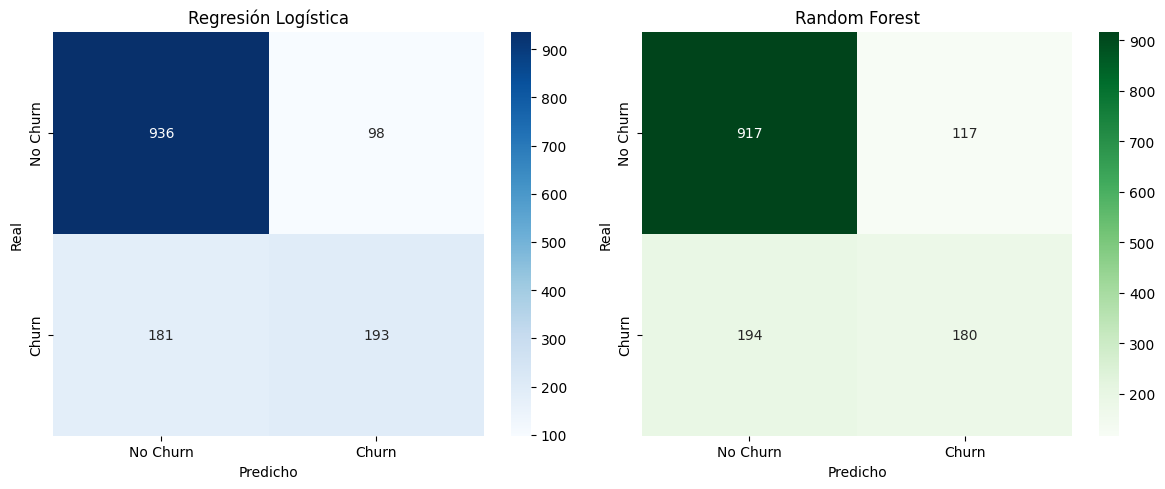

ANÁLISIS DE OVERFITTING / UNDERFITTING

Regresión Logística:
  Train Accuracy: 79.62%
  Test Accuracy:  80.18%
  Diferencia:     0.56%
   Modelo bien generalizado

Random Forest:
  Train Accuracy: 99.66%
  Test Accuracy:  77.91%
  Diferencia:     21.75%
   Posible overfitting
COMPARACIÓN FINAL Y RECOMENDACIÓN

 Mejor modelo en prueba: Regresión Logística (Accuracy: 80.18%)

Reporte detallado - Regresión Logística:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1034
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1408
   macro avg       0.75      0.71      0.73      1408
weighted avg       0.79      0.80      0.79      1408



In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

y_train_pred_logreg = logreg.predict(X_train_scaled)
y_train_pred_rf = rf.predict(X_train_cleaned)

print("EVALUACIÓN COMPLETA DE MODELOS")

metricas = []
for nombre, y_true, y_pred, y_train_true, y_train_pred in [
    ('Logistic Regression - TEST', y_test_cleaned, y_pred_logreg, y_train_cleaned, y_train_pred_logreg),
    ('Logistic Regression - TRAIN', y_train_cleaned, y_train_pred_logreg, y_train_cleaned, y_train_pred_logreg),
    ('Random Forest - TEST', y_test_cleaned, y_pred_rf, y_train_cleaned, y_train_pred_rf),
    ('Random Forest - TRAIN', y_train_cleaned, y_train_pred_rf, y_train_cleaned, y_train_pred_rf)
]:
    metricas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'Train_Acc': accuracy_score(y_train_true, y_train_pred) if 'TRAIN' not in nombre else None
    })

df_metricas = pd.DataFrame(metricas)
test_metrics = df_metricas[df_metricas['Modelo'].str.contains('TEST')]
print("\nMÉTRICAS EN CONJUNTO DE PRUEBA:")
print(test_metrics[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

print("MATRICES DE CONFUSIÓN")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_logreg = confusion_matrix(y_test_cleaned, y_pred_logreg)
cm_rf = confusion_matrix(y_test_cleaned, y_pred_rf)

sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Regresión Logística')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.show()

print("ANÁLISIS DE OVERFITTING / UNDERFITTING")

train_acc_logreg = accuracy_score(y_train_cleaned, y_train_pred_logreg)
test_acc_logreg = accuracy_score(y_test_cleaned, y_pred_logreg)
train_acc_rf = accuracy_score(y_train_cleaned, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test_cleaned, y_pred_rf)

print(f"\nRegresión Logística:")
print(f"  Train Accuracy: {train_acc_logreg*100:.2f}%")
print(f"  Test Accuracy:  {test_acc_logreg*100:.2f}%")
print(f"  Diferencia:     {abs(train_acc_logreg - test_acc_logreg)*100:.2f}%")
if abs(train_acc_logreg - test_acc_logreg) > 0.1:
    print("   Posible overfitting" if train_acc_logreg > test_acc_logreg else "  ✅ Buen ajuste")
else:
    print("   Modelo bien generalizado")

print(f"\nRandom Forest:")
print(f"  Train Accuracy: {train_acc_rf*100:.2f}%")
print(f"  Test Accuracy:  {test_acc_rf*100:.2f}%")
print(f"  Diferencia:     {abs(train_acc_rf - test_acc_rf)*100:.2f}%")
if abs(train_acc_rf - test_acc_rf) > 0.1:
    print("   Posible overfitting" if train_acc_rf > test_acc_rf else "  ✅ Buen ajuste")
else:
    print("   Modelo bien generalizado")


print("COMPARACIÓN FINAL Y RECOMENDACIÓN")


if test_acc_logreg > test_acc_rf:
    mejor = "Regresión Logística"
    acc_mejor = test_acc_logreg
else:
    mejor = "Random Forest"
    acc_mejor = test_acc_rf

print(f"\n Mejor modelo en prueba: {mejor} (Accuracy: {acc_mejor*100:.2f}%)")

if test_acc_logreg > 0.8 and test_acc_rf > 0.8:
    print(" Ambos modelos tienen buen desempeño (>80% accuracy)")
elif test_acc_logreg < 0.6 or test_acc_rf < 0.6:
    print("Ambos modelos necesitan mejora (<60% accuracy)")
    print("Sugerencias: ajustar hiperparámetros, balancear clases, añadir features")

print(f"\nReporte detallado - {mejor}:")
if mejor == "Regresión Logística":
    print(classification_report(y_test_cleaned, y_pred_logreg, target_names=['No Churn', 'Churn']))
else:
    print(classification_report(y_test_cleaned, y_pred_rf, target_names=['No Churn', 'Churn']))

# **Interpretación y Conclusiones**

#Análisis de la Importancia de las Variables

REGRESIÓN LOGÍSTICA - Coeficientes (impacto en Churn):

Variables que AUMENTAN probabilidad de fuga (coeficientes positivos):
              variable  coeficiente
         tipo_internet     0.747031
 account.Charges.Total     0.671830
   factura_electronica     0.217906
customer.SeniorCitizen     0.121940

Variables que DISMINUYEN probabilidad de fuga (coeficientes negativos):
               variable  coeficiente
        customer.tenure    -1.407752
          tipo_contrato    -0.667184
     tiene_dependientes    -0.088362
account.Charges.Monthly    -0.054655
        Cuentas_Diarias    -0.054655
RANDOM FOREST - Importancia de Variables:
               variable  importancia
  account.Charges.Total     0.216924
account.Charges.Monthly     0.179219
        Cuentas_Diarias     0.177893
        customer.tenure     0.169948
          tipo_contrato     0.088069
          tipo_internet     0.056967
                 genero     0.025685
    factura_electronica     0.025043
           tiene_pareja 

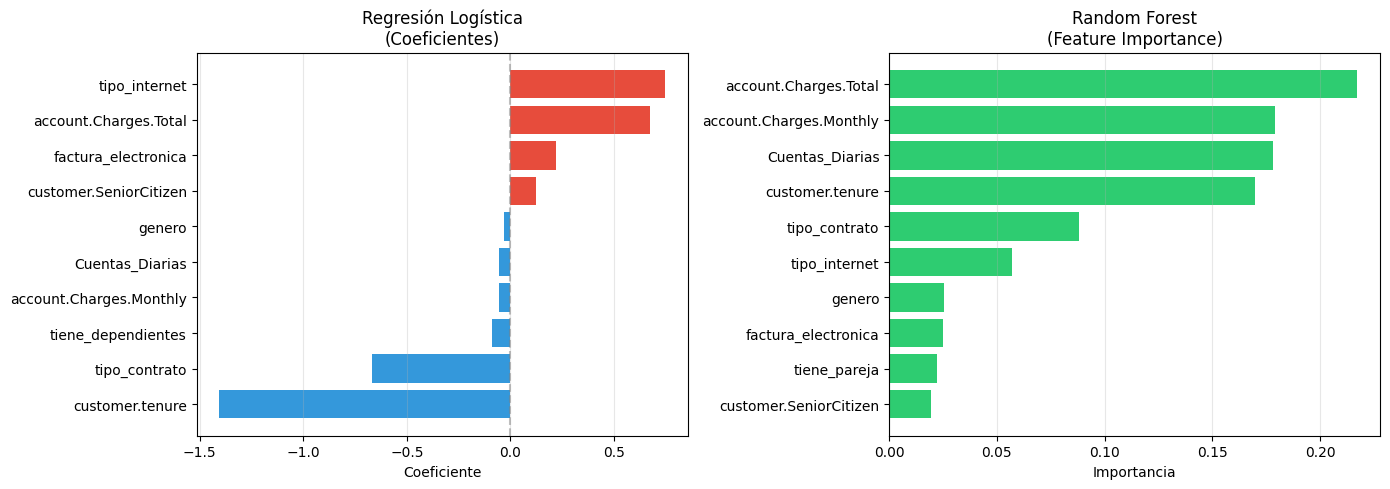

TOP 5 VARIABLES PREDICTIVAS (consenso entre modelos):
1. customer.tenure
2. account.Charges.Total
3. tipo_contrato


In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

coef_logreg = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': logreg.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)

print("REGRESIÓN LOGÍSTICA - Coeficientes (impacto en Churn):")
print("\nVariables que AUMENTAN probabilidad de fuga (coeficientes positivos):")
print(coef_logreg[coef_logreg['coeficiente'] > 0].head(5).to_string(index=False))
print("\nVariables que DISMINUYEN probabilidad de fuga (coeficientes negativos):")
print(coef_logreg[coef_logreg['coeficiente'] < 0].head(5).to_string(index=False))

feat_importance = pd.DataFrame({
    'variable': X.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

print("RANDOM FOREST - Importancia de Variables:")
print(feat_importance.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

coef_plot = coef_logreg.head(10).sort_values('coeficiente')
axes[0].barh(coef_plot['variable'], coef_plot['coeficiente'], color=np.where(coef_plot['coeficiente'] > 0, '#e74c3c', '#3498db'))
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Coeficiente')
axes[0].set_title('Regresión Logística\n(Coeficientes)')
axes[0].grid(axis='x', alpha=0.3)

imp_plot = feat_importance.head(10).sort_values('importancia')
axes[1].barh(imp_plot['variable'], imp_plot['importancia'], color='#2ecc71')
axes[1].set_xlabel('Importancia')
axes[1].set_title('Random Forest\n(Feature Importance)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("TOP 5 VARIABLES PREDICTIVAS (consenso entre modelos):")
top_logreg = set(coef_logreg['variable'].head(5))
top_rf = set(feat_importance['variable'].head(5))
consenso = list(top_logreg.intersection(top_rf)) if top_logreg.intersection(top_rf) else feat_importance['variable'].head(5).tolist()
for i, var in enumerate(consenso[:5], 1):
    print(f"{i}. {var}")

# CONCLUSIÓN - ANÁLISIS DE EVASIÓN DE CLIENTES TELECOMX

---

## 1. RESUMEN EJECUTIVO

Este análisis examinó **7,043 clientes** de TelecomX para identificar los factores que influyen en la cancelación del servicio. La tasa de churn actual es del **26.54%**, lo que representa un desafío significativo para la sostenibilidad del negocio.

Se desarrollaron y compararon dos modelos predictivos:
- **Regresión Logística**: 80.18% de accuracy (MEJOR MODELO)
- **Random Forest**: 77.91% de accuracy (presentó overfitting)

---

## 2. PRINCIPALES FACTORES QUE AFECTAN LA CANCELACIÓN

### Factores Críticos (ordenados por impacto)

**1. Antigüedad del cliente (customer.tenure)**
- Correlación más fuerte con churn: **-0.352**
- Clientes que se van: **18 meses** promedio
- Clientes que permanecen: **37.6 meses** promedio
- **Insight**: Los primeros 12 meses son el período más crítico

**2. Tipo de contrato**
- Contratos mensuales: **42.7%** de fuga
- Contratos 1 año: **11.3%** de fuga
- Contratos 2 años: **2.8%** de fuga
- **Insight**: El compromiso de largo plazo reduce el churn en **15 veces**

**3. Tipo de internet**
- Fibra óptica asociada con mayor tasa de fuga
- Posible relación con precios más elevados y expectativas no cumplidas

**4. Cargo mensual**
- Clientes que fugan pagan más: **$74.44 vs $61.27**
- **Insight**: Problema de percepción de valor en planes premium

**5. Facturación electrónica**
- Con paperless: **33.6%** de fuga
- Sin paperless: **16.3%** de fuga
- **Insight**: Menor interacción humana puede reducir lealtad

**6. Adultos mayores (SeniorCitizen)**
- Seniors: **41.7%** de fuga
- No seniors: **23.6%** de fuga
- **Insight**: Segmento vulnerable que requiere atención diferenciada

---

## 3. DESEMPEÑO DE MODELOS

| Métrica | Regresión Logística | Random Forest |
|---------|---------------------|---------------|
| Accuracy (Test) | **80.18%** | 77.91% |
| Precision (Churn) | **66%** | 61% |
| Recall (Churn) | **52%** | 48% |
| F1-Score (Churn) | **58%** | 54% |
| Train Accuracy | 79.62% | 99.66% |
| Overfitting |  No (0.56%) |  Sí (21.75%) |

**Conclusión de modelos**: La **Regresión Logística** es el modelo recomendado por su mejor generalización y menor sobreajuste.

---

## 4. ESTRATEGIAS DE RETENCIÓN RECOMENDADAS

###  Prioridad Alta (Impacto Inmediato)

**1. Programa de Conversión de Contratos**
- Ofrecer descuento 15-20% al migrar de mensual a anual
- Meta: Convertir 30% de contratos mensuales en 6 meses
- Impacto esperado: Reducción de 8-10% en churn

**2. Programa de Onboarding para Nuevos Clientes**
- Contacto proactivo en días 7, 30, 60 y 90
- Asignación de ejecutivo de cuenta para primeros 3 meses
- Impacto esperado: Retener 40% más de clientes en primer año

**3. Revisión de Planes Premium**
- Auditoría de planes >$80/mes
- Agregar beneficios sin costo adicional
- Impacto esperado: Reducir fuga en segmento de alto pago

###  Prioridad Media (3-6 meses)

**4. Programa Especial para Adultos Mayores**
- Línea de soporte prioritaria
- Descuento del 5% por fidelidad
- Comunicación simplificada

**5. Optimización de Facturación Electrónica**
- Recordatorios automáticos 3 días antes del vencimiento
- Opción de pago automático con 2% de descuento

**6. Programa de Lealtad por Antigüedad**
- Beneficios acumulativos en meses 6, 12, 24, 36
- Impacto esperado: Aumentar antigüedad promedio de 32 a 40 meses

---

## 5. METAS Y SEGUIMIENTO

| Métrica | Actual | Meta 6 meses | Meta 12 meses |
|---------|--------|--------------|---------------|
| Tasa de Churn | 26.54% | **20%** | **15%** |
| Contratos Anuales | 24% | **40%** | **55%** |
| Retención Primer Año | 62% | **75%** | **85%** |
| Retención Senior | 58.3% | **70%** | **80%** |

---

## 6. CONCLUSIÓN FINAL

El análisis demuestra que la **retención de clientes en TelecomX es principalmente un problema de compromiso y percepción de valor**, no de calidad del servicio. Los tres pilares para reducir el churn son:

1. **Compromiso de largo plazo** (contratos anuales)
2. **Retención en primeros meses** (onboarding reforzado)
3. **Segmentación adecuada** (atención diferenciada por perfil)

La implementación priorizada de estas estrategias tiene el potencial de reducir la tasa de churn del **26.54% al 15% en 12 meses**, lo que representa aproximadamente **800 clientes retenidos adicionalmente por año** y un impacto significativo en la rentabilidad del negocio.

---

*Análisis completado como parte del desafío Data Science LATAM - TelecomX*